In [1]:
import pandas as pd
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

connection_url = URL.create(
    "mysql+pymysql",
    username="root",
    password="Aditya@123",
    host="localhost",
    port=3306,
    database="retail_forecasting"
)

engine = create_engine(connection_url)

df = pd.read_sql("SELECT * FROM retail_sales", engine)

df["Date"] = pd.to_datetime(df["Date"])

df.head()

,Date,Store_ID,Product_ID,Category,Region,Inventory_Level,Units_Sold,Units_Ordered,Price,Discount,Weather_Condition,Promotion,Competitor_Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [2]:
daily_demand = (
    df.groupby("Date")["Demand"]
      .sum()
      .reset_index()
)

daily_demand.head()

,Date,Demand
0,2022-01-01,10060
1,2022-01-02,10814
2,2022-01-03,11317
3,2022-01-04,11469
4,2022-01-05,11724


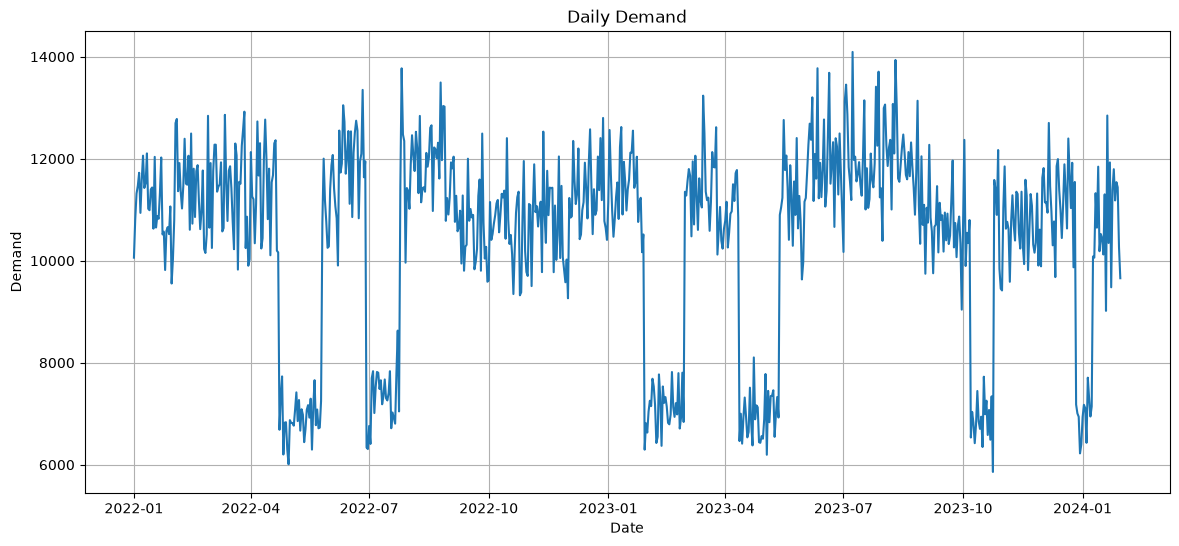

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    daily_demand["Date"],
    daily_demand["Demand"]
)

plt.title("Daily Demand")
plt.xlabel("Date")
plt.ylabel("Demand")

plt.grid(True)
plt.show()

In [4]:
daily_demand = daily_demand.set_index("Date")
daily_demand = daily_demand.asfreq("D")   # Add this line

daily_demand.head()

,Demand
Date,
2022-01-01,10060
2022-01-02,10814
2022-01-03,11317
2022-01-04,11469
2022-01-05,11724


In [5]:
print("Missing values:")
print(daily_demand.isnull().sum())

Missing values:
Demand    0
dtype: int64


In [6]:
train = daily_demand.iloc[:-30]
test = daily_demand.iloc[-30:]

print(train.shape)
print(test.shape)

(730, 1)
(30, 1)


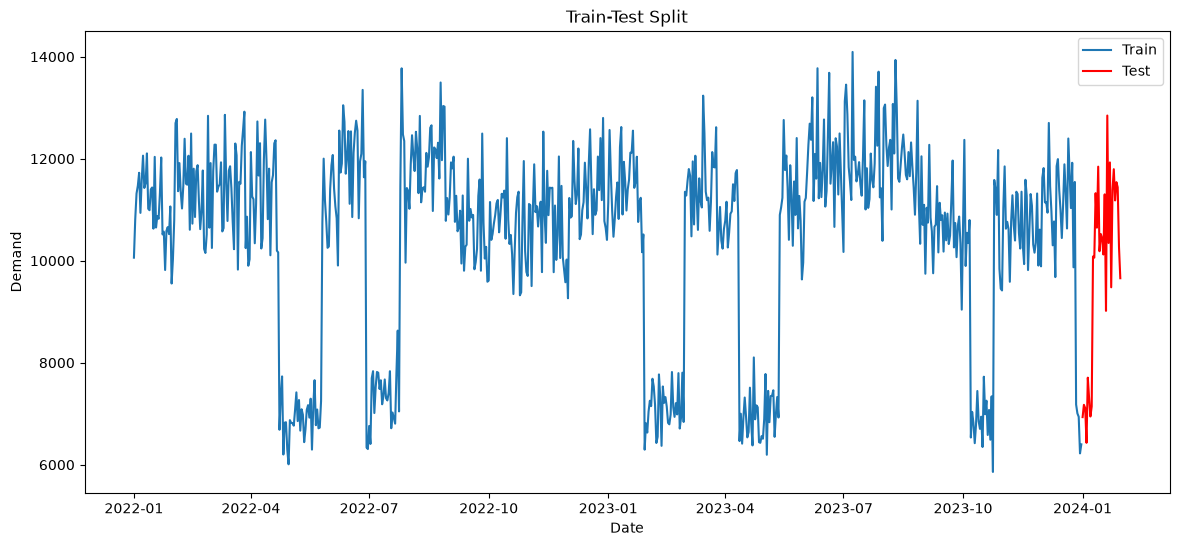

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(train.index, train["Demand"], label="Train")
plt.plot(test.index, test["Demand"], label="Test", color="red")

plt.title("Train-Test Split")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()

plt.show()

In [8]:
from statsmodels.tsa.arima.model import ARIMA

In [9]:
model = ARIMA(train["Demand"], order=(5,1,0))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                 Demand   No. Observations:                  730
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -6080.311
Date:                Sun, 19 Jul 2026   AIC                          12172.621
Time:                        04:14:28   BIC                          12200.172
Sample:                    01-01-2022   HQIC                         12183.251
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3949      0.027    -14.466      0.000      -0.448      -0.341
ar.L2         -0.1595      0.042     -3.768      0.000      -0.242      -0.077
ar.L3         -0.1183      0.038     -3.082      0.0

In [10]:
forecast = model_fit.forecast(steps=30)

print(forecast)

2024-01-01    6706.955162
2024-01-02    6659.552417
2024-01-03    6698.214653
2024-01-04    6671.366665
2024-01-05    6635.010352
2024-01-06    6638.340978
2024-01-07    6643.888760
2024-01-08    6646.625065
2024-01-09    6650.076187
2024-01-10    6649.167080
2024-01-11    6647.806349
2024-01-12    6647.454362
2024-01-13    6647.356318
2024-01-14    6647.536641
2024-01-15    6647.735046
2024-01-16    6647.754731
2024-01-17    6647.724625
2024-01-18    6647.693471
2024-01-19    6647.674728
2024-01-20    6647.677667
2024-01-21    6647.685748
2024-01-22    6647.689664
2024-01-23    6647.690404
2024-01-24    6647.689181
2024-01-25    6647.687954
2024-01-26    6647.687642
2024-01-27    6647.687807
2024-01-28    6647.688044
2024-01-29    6647.688174
2024-01-30    6647.688169
Freq: D, Name: predicted_mean, dtype: float64


In [11]:
daily_demand = daily_demand.asfreq("D")

In [12]:
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                 Demand   No. Observations:                  730
Model:                 ARIMA(5, 1, 0)   Log Likelihood               -6080.311
Date:                Sun, 19 Jul 2026   AIC                          12172.621
Time:                        04:14:28   BIC                          12200.172
Sample:                    01-01-2022   HQIC                         12183.251
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3949      0.027    -14.466      0.000      -0.448      -0.341
ar.L2         -0.1595      0.042     -3.768      0.000      -0.242      -0.077
ar.L3         -0.1183      0.038     -3.082      0.0

In [13]:
forecast = model_fit.forecast(steps=len(test))

forecast.head()

2024-01-01    6706.955162
2024-01-02    6659.552417
2024-01-03    6698.214653
2024-01-04    6671.366665
2024-01-05    6635.010352
Freq: D, Name: predicted_mean, dtype: float64

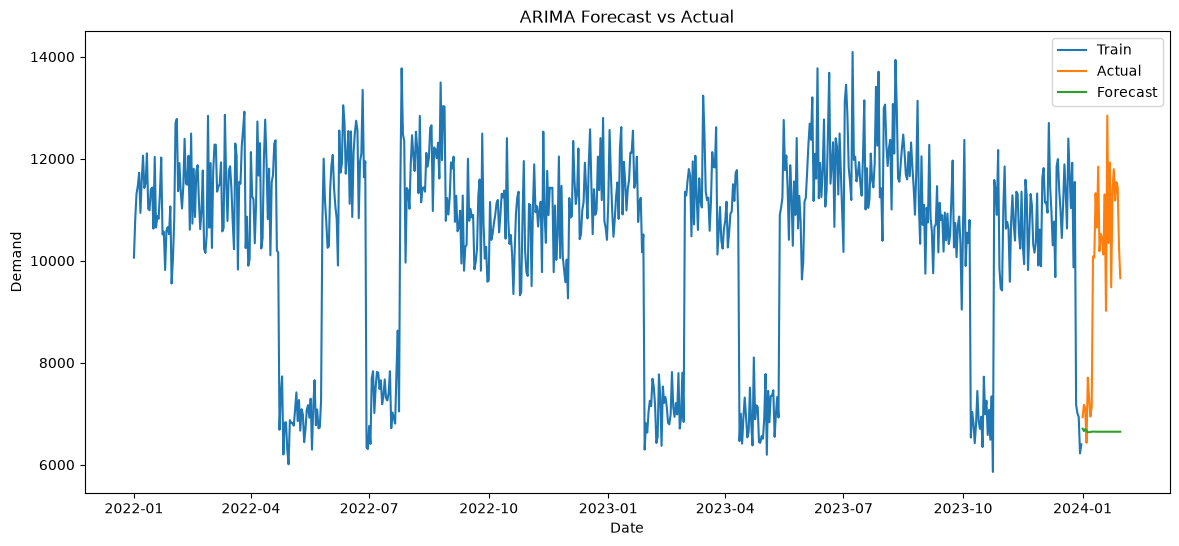

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(train.index, train["Demand"], label="Train")
plt.plot(test.index, test["Demand"], label="Actual")
plt.plot(test.index, forecast, label="Forecast")

plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.legend()

plt.show()

In [15]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(test["Demand"], forecast)
rmse = np.sqrt(mean_squared_error(test["Demand"], forecast))
r2 = r2_score(test["Demand"], forecast)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)


MAE: 3169.641309505656
RMSE: 3644.906560368828
R2: -3.00560923355828
